In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

### Dataset presentation and features

Crop Health and Environmental Stress Dataset
Dataset Overview: 
- multiple agricultural regions in Netherlands 
- 212,019 records, collected through satellite imagery, UAV-based remote sensing, weather stations, and on-field sensors 

Purpose of the Dataset
- Crop Health Prediction: Identify healthy vs. unhealthy crops based on multispectral and thermal imaging.
- Pest & Weed Monitoring: Analyze pest infestations and weed presence affecting plant growth.
- Environmental Stress Analysis: Evaluate the impact of soil, climate, and water availability on plant health.
- Remote Sensing Applications: Leverage UAV and satellite imagery for agricultural research.
- Decision Support for Farmers: Develop automated decision-making systems for smart agriculture.

The data sources include:
- Multispectral and Thermal Cameras (UAVs & Satellite Imagery)
= Field Sensors & Weather Stations (Soil moisture, pH, temperature, humidity)
- Manual Crop Inspections & Yield Estimates (Human-labeled data)
- Geospatial Data Processing (NDVI, SAVI, Chlorophyll Content, etc.)

All data has been preprocessed and cleaned, ensuring high reliability for ML/DL applications.


In [3]:
df_features = pd.read_csv("dataset_features.csv")
with pd.option_context('display.max_colwidth', None):
    display(df_features[["Feature Name", "Description", "Data Type"]])

,Feature Name,Description,Data Type
0,High_Resolution_RGB,Availability of high-resolution RGB images (1 = Yes; 0 = No),Binary
1,Multispectral_Images,Presence of multispectral satellite imagery (1 = Yes; 0 = No),Binary
2,Thermal_Images,Usage of thermal imaging to analyze crop temperature variations (1 = Yes; 0 = No),Binary
3,Temporal_Images,Availability of time-series crop images (1 = Yes; 0 = No),Binary
4,Spatial_Resolution,Spatial resolution of the captured image (in meters),Float
5,GPS_Coordinates,Unique field location identifiers based on GPS mapping,Integer
6,Field_Boundaries,Categorized field boundary types (1; 2; 3),Categorical
7,Elevation_Data,Altitude of the agricultural plot (in meters),Float
8,Canopy_Coverage,Percentage of plant canopy coverage over soil,Float
9,NDVI,Normalized Difference Vegetation Index (0 to 1 scale),Float


### Dataset acquaintance

In [4]:
df = pd.read_csv("agriculture_dataset.csv")

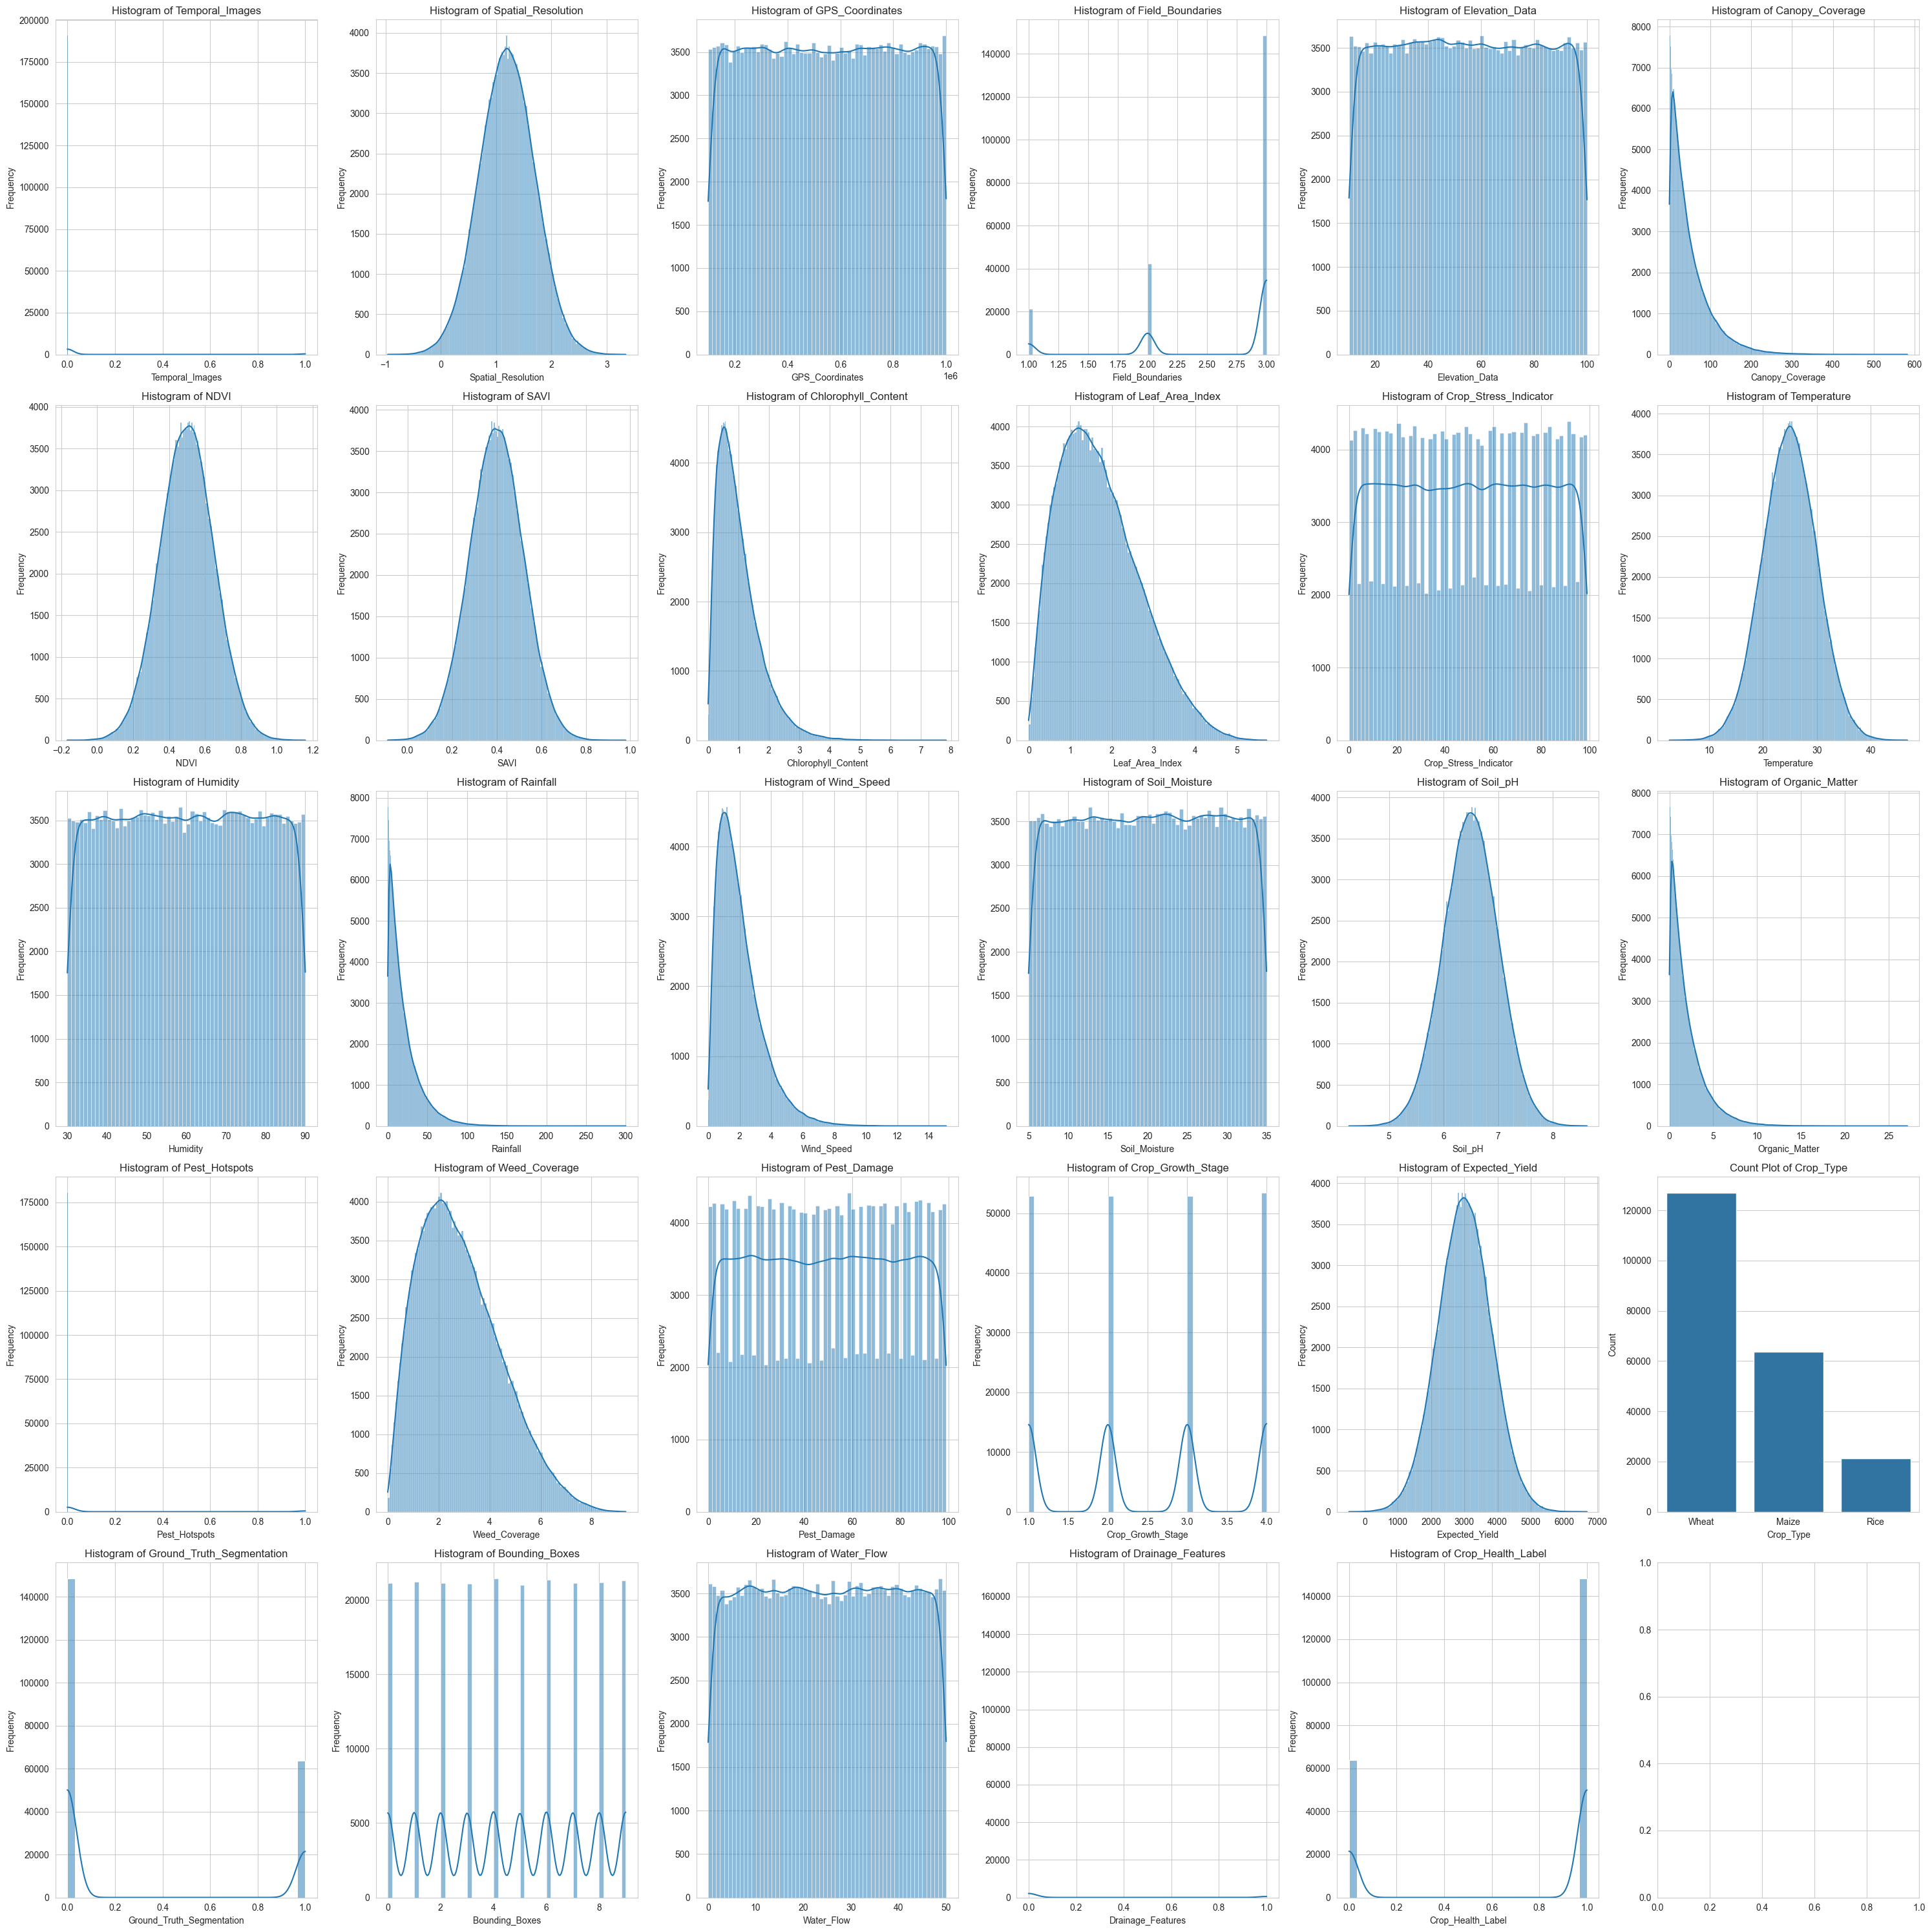

In [5]:
#plots for each feature
# Set the style of the plots
sns.set_style("whitegrid")
# List of features to plot
features = df.columns[3:]  # Exclude the first column (ID)
# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(30, 30))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through each feature and create a plot
for i, feature in enumerate(features):
    if df[feature].dtype == 'object':  # Categorical feature
        sns.countplot(x=feature, data=df, ax=axes[i])
        axes[i].set_title(f'Count Plot of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')
    else:  # Numerical feature
        sns.histplot(df[feature], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
# Adjust layout
plt.tight_layout()
plt.show()

#erreur sur temporal images, drainage features et pest hotspots pcq on voit pas la barre de l'histogramme

Possible labels we could want to predict

8.   Canopy_Coverage	Percentage of plant canopy coverage over soil	Float
9.	NDVI	Normalized Difference Vegetation Index (0 to 1 scale)	Float
10.	SAVI	Soil-Adjusted Vegetation Index for correcting soil effects	Float
11.	Chlorophyll_Content	Chlorophyll level measurement to assess crop health	Float
12.	Leaf_Area_Index	Ratio of total leaf area per ground area unit	Float
13.	Crop_Stress_Indicator Stress level assessment (0 = No Stress; 100 = Extreme Stress)	Integer

18.	Soil_Moisture	Soil water retention percentage	Float
19.	Soil_pH	pH level of the soil sample collected	Float
20.	Organic_Matter	Organic carbon and nutrients present in soil (g/kg)	Float
21.	Pest_Hotspots	Indicator for pest-affected areas (1 = Yes; 0 = No)	Binary
22.	Weed_Coverage	Percentage of weed coverage in the field	Float
23.	Pest_Damage	Severity of pest damage on crops (0-100)	Integer
24.	Crop_Growth_Stage	Growth phase of the crop (1 = Early; 2 = Vegetative; 3 = Flowering; 4 = Maturity)	Categorical
25.	Expected_Yield	Predicted yield of the crop (kg/ha)	Float

31.	Crop_Health_Label	Target variable indicating crop condition (0 = Unhealthy; 1 = Healthy)	Binary

=> where does it come from?
To what extent are they interdependant?
We can make models to predict certain values based an meteo into predicting health at the end.

Focus on
- crop health label
- expected yield

<Axes: xlabel='Pest_Hotspots', ylabel='Count'>

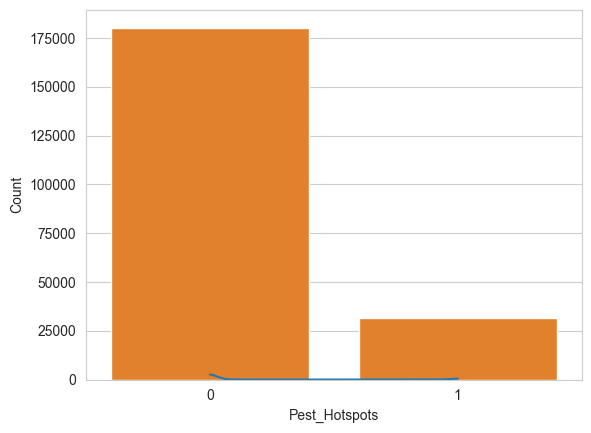

In [ ]:
# histogram for pest hotspots
sns.histplot(df["Pest_Hotspots"], kde=True)
sns.countplot(x="Pest_Hotspots", data=df)

### Interdependance analysis

Text(0.5, 1.0, 'Correlation Matrix of Features')

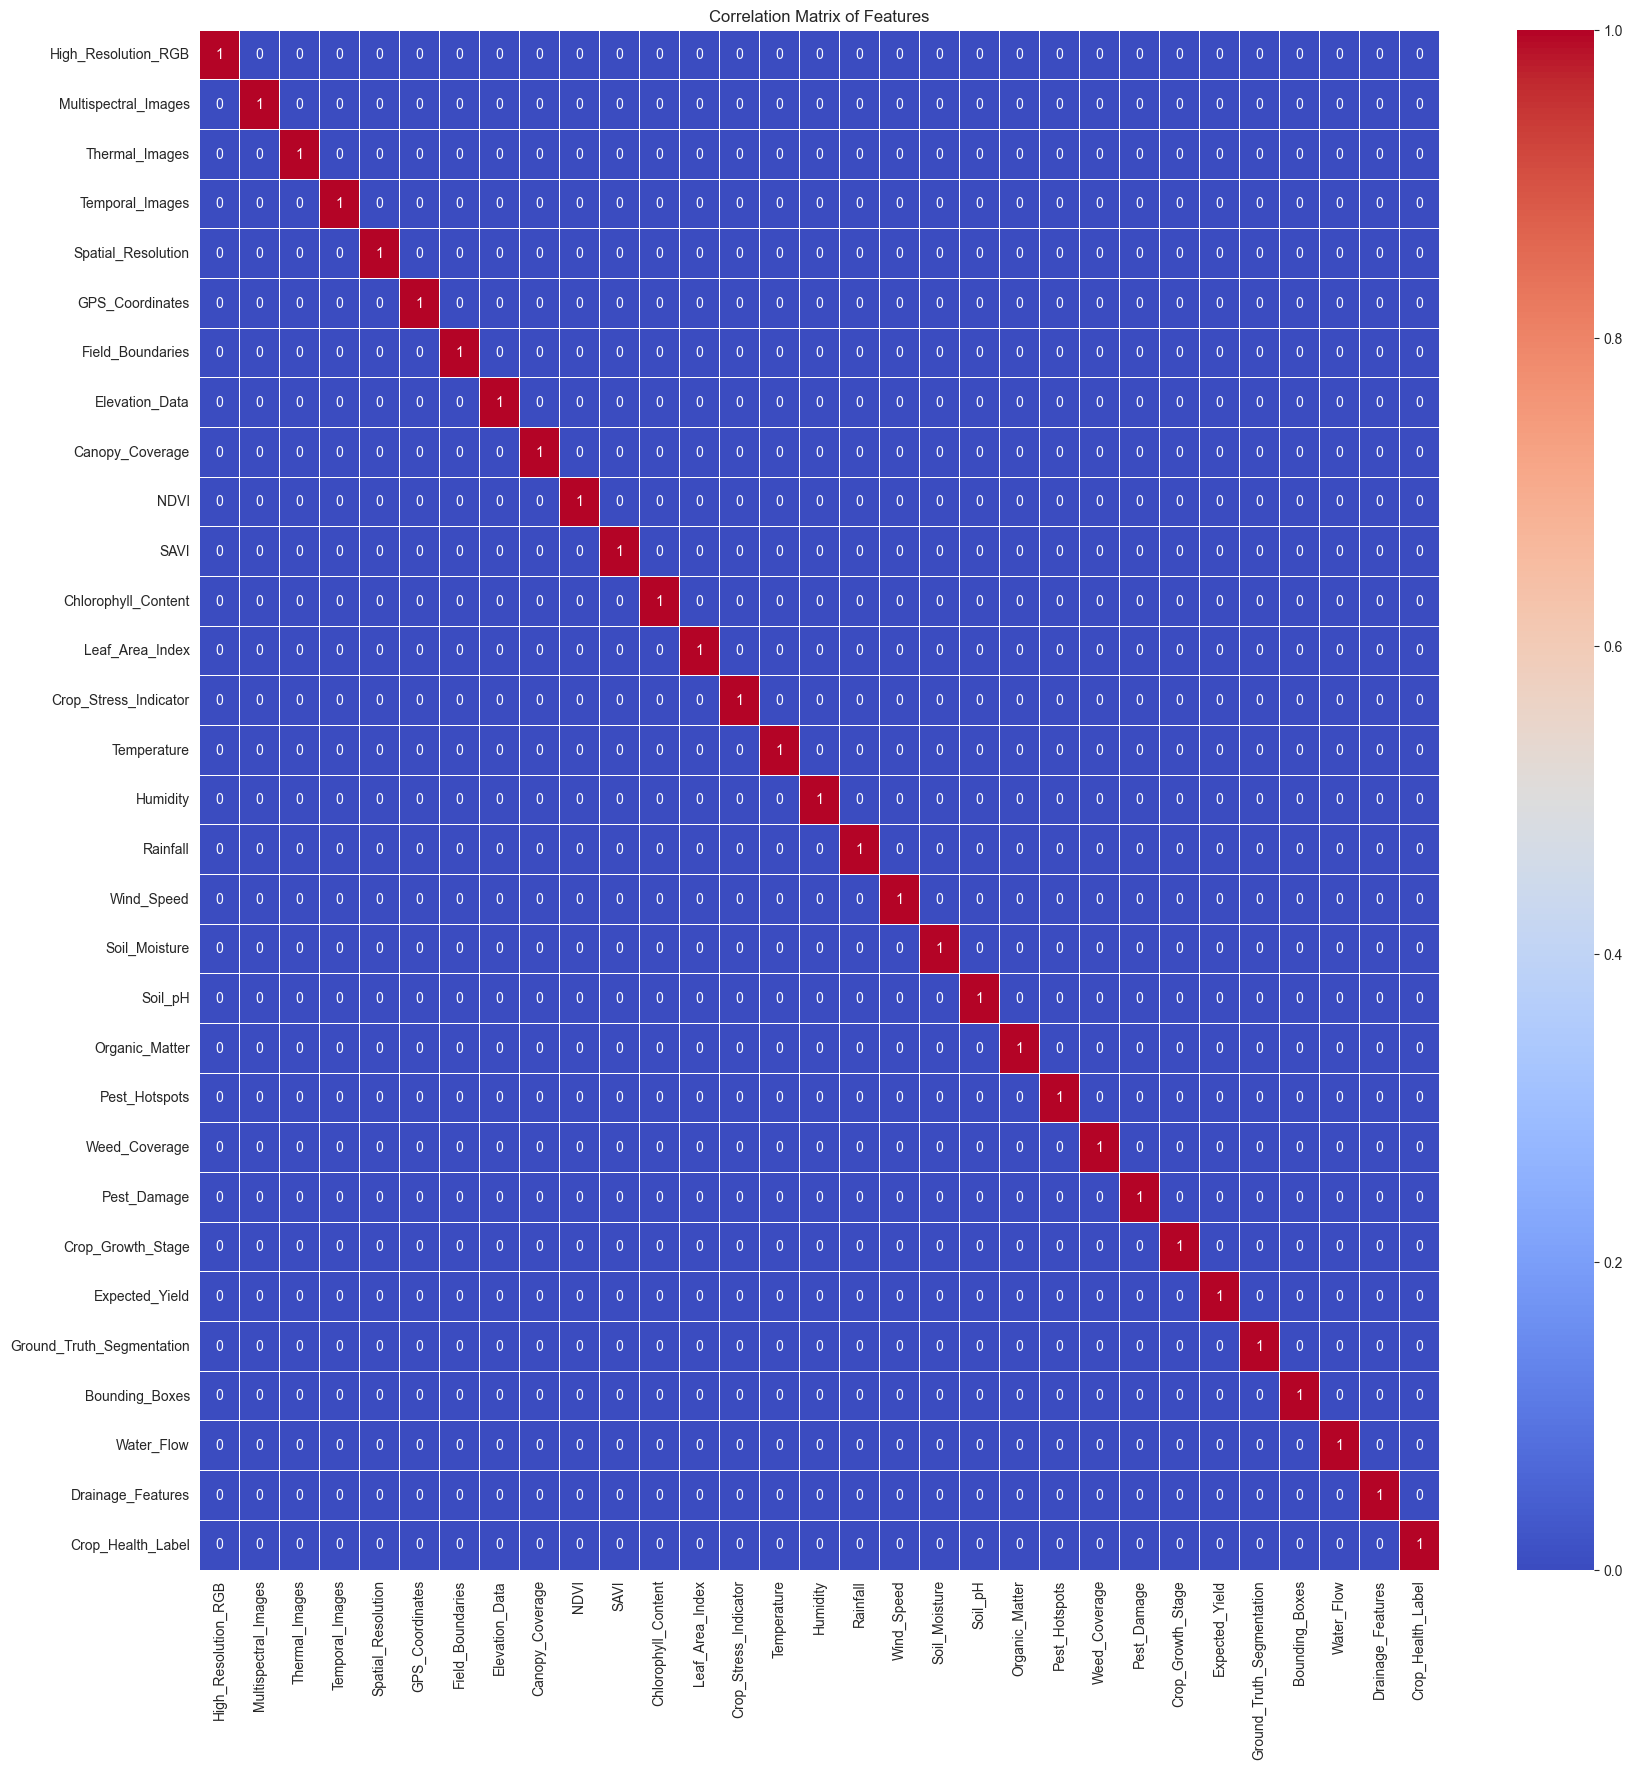

In [7]:
#linear correlation between features
#select features that are numerical for correlation matrix
features = df.select_dtypes(include=[np.number]).columns.tolist()

#how much are columns related? (we truncate above 0.1 to make it more readable)
correlation_matrix = df[features].corr()
correlation_matrix[correlation_matrix < 0.1] = 0
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')

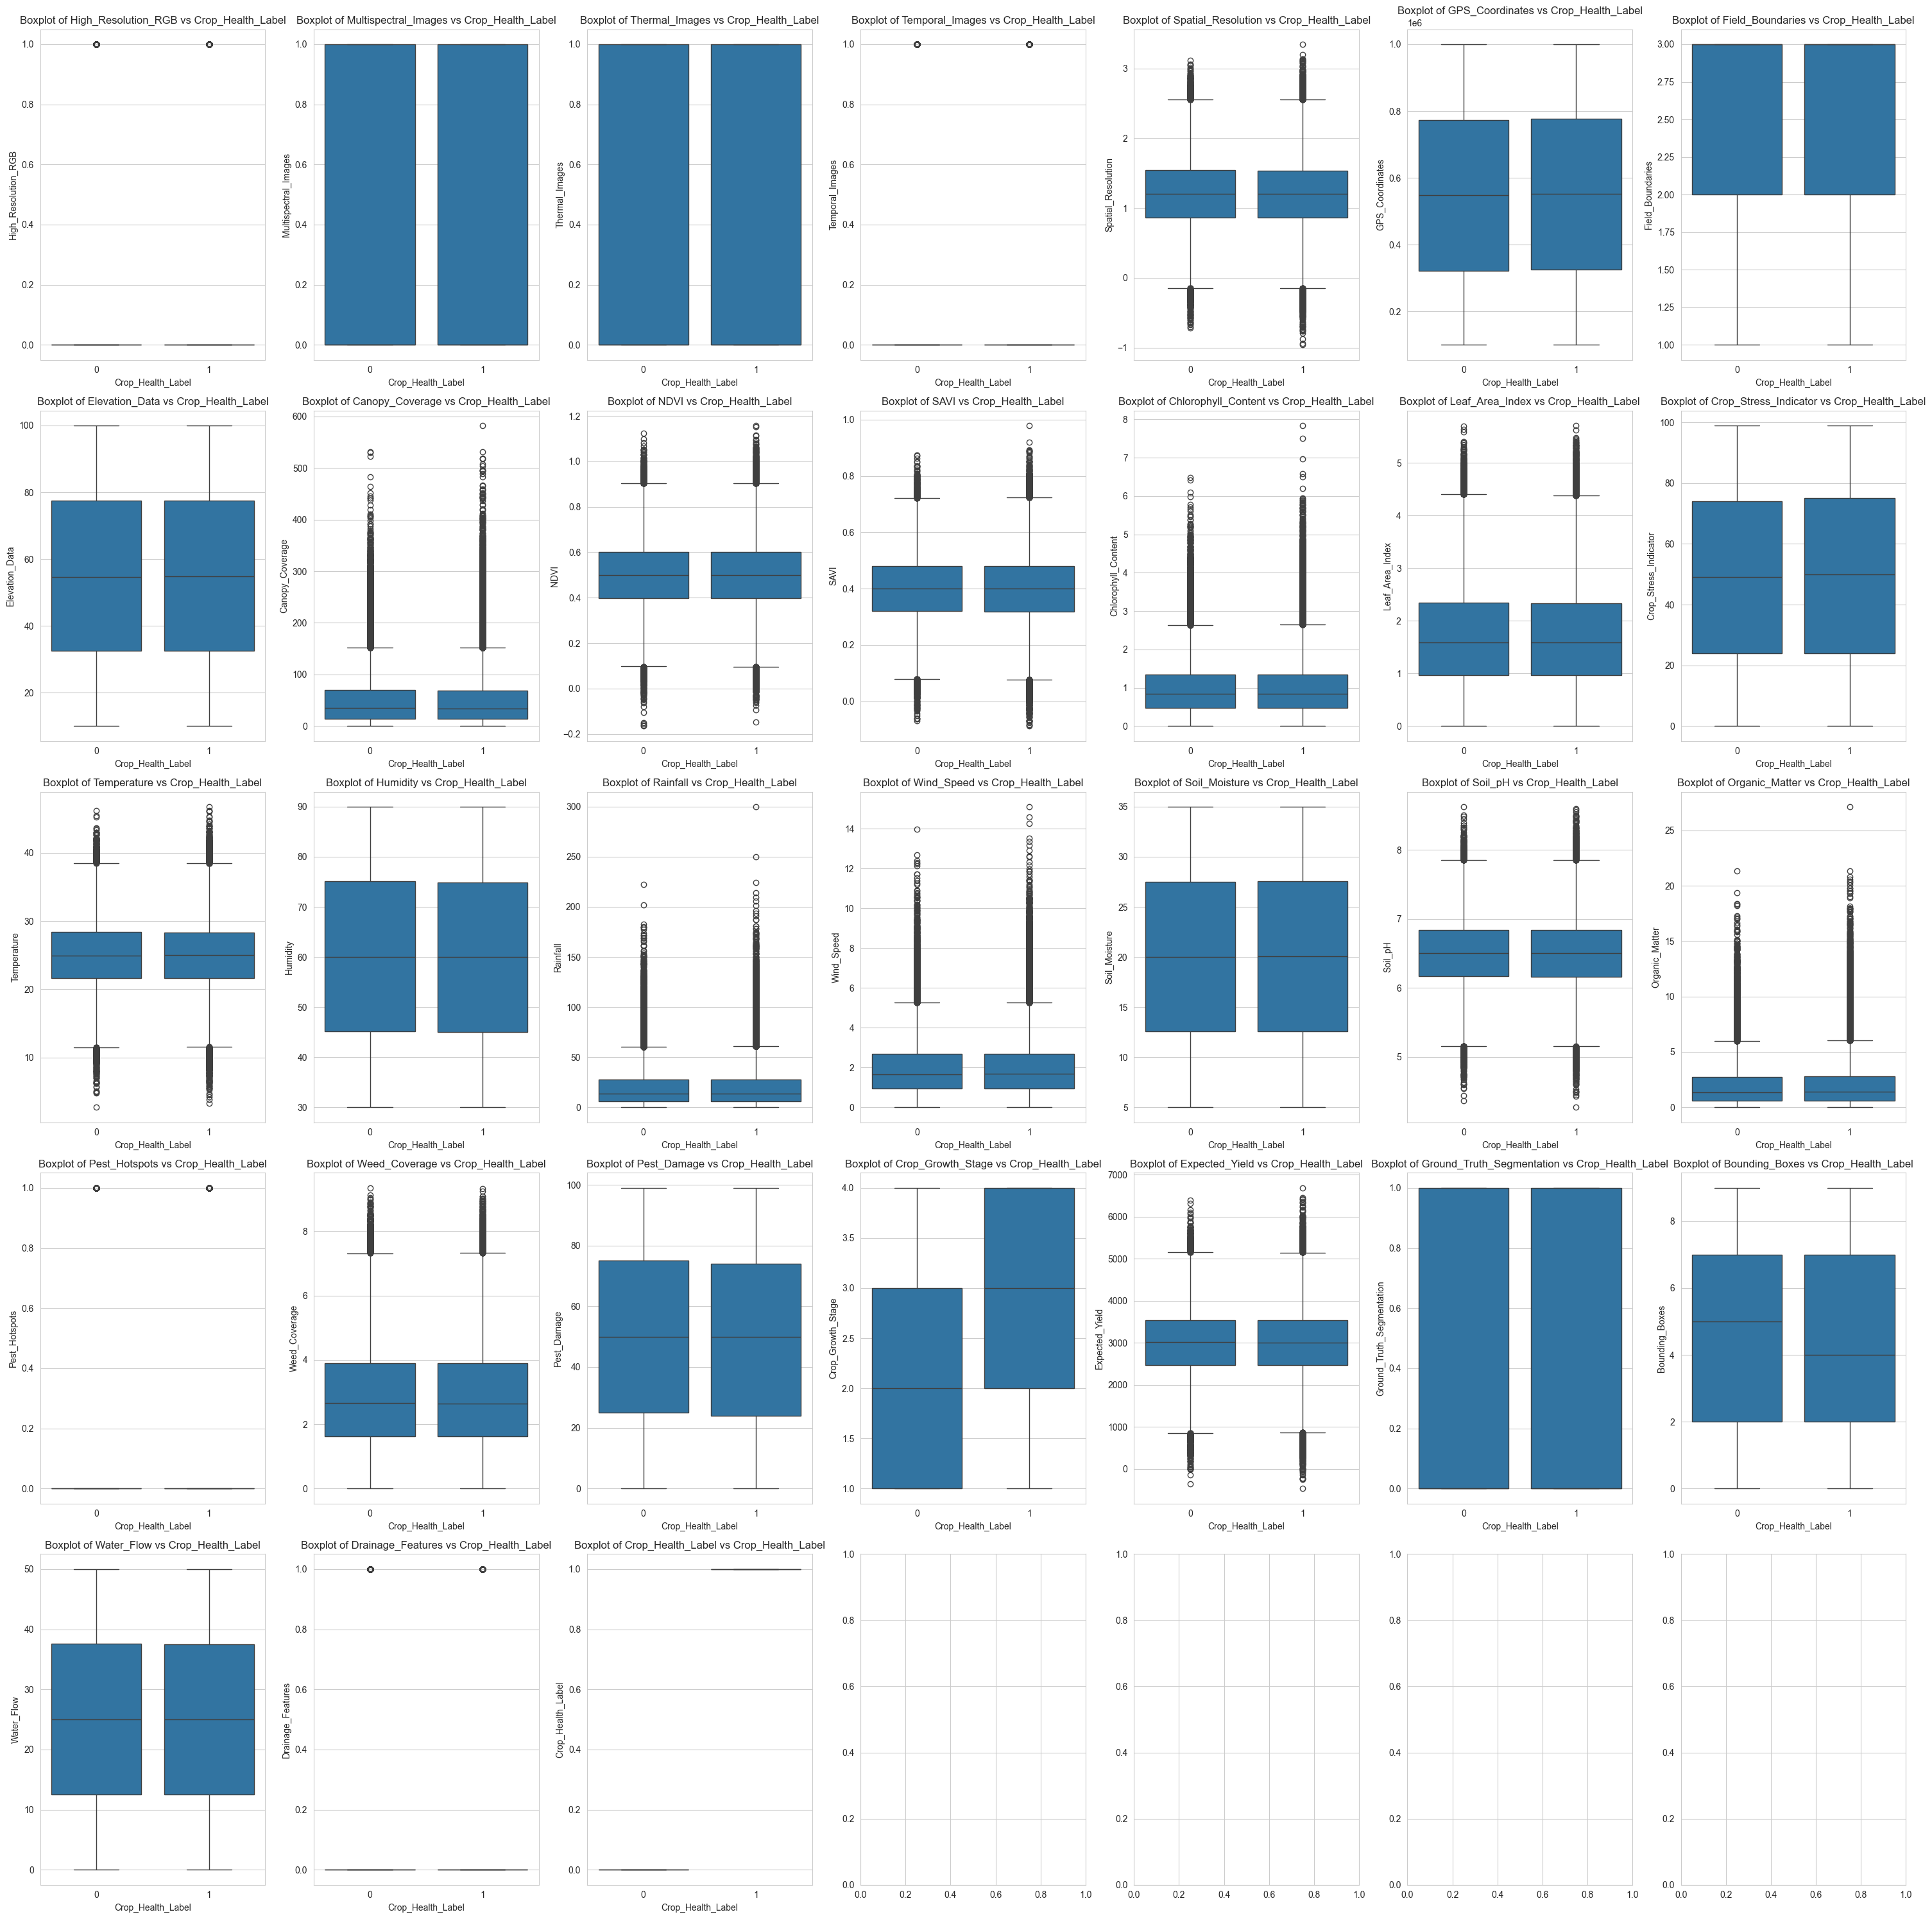

In [8]:
# Look at impact of variance of features on the target variable: Crop_Health_Label

# We can use boxplots to visualize the relationship between each feature and the target variable
# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=7, figsize=(30, 30))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
# Loop through each feature and create a boxplot
for i, feature in enumerate(features):
    sns.boxplot(x="Crop_Health_Label", y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} vs Crop_Health_Label')
    axes[i].set_xlabel('Crop_Health_Label')
    axes[i].set_ylabel(feature)
# Adjust layout
plt.tight_layout()
plt.show()


### PCA draft analysis

In [28]:
# take only features of interest for PCA
print(features)
features_pca = ['Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI', 'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture', 'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage', 'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Water_Flow', 'Crop_Health_Label']

['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images', 'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates', 'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI', 'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture', 'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage', 'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow', 'Drainage_Features', 'Crop_Health_Label']


Text(0.5, 1.0, 'PCA of Crop Health Dataset')

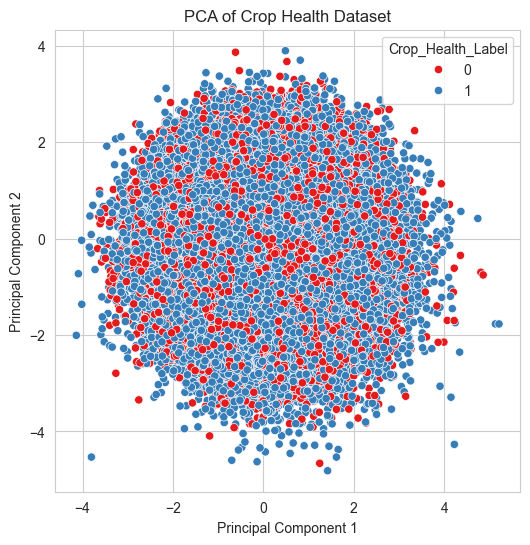

In [29]:
# PCA to visualize the data in 2D

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_pca[:-1]])  # Exclude the target variable
# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Crop_Health_Label'] = df['Crop_Health_Label']
# Visualize the PCA results
plt.figure(figsize=(6, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Crop_Health_Label', data=pca_df, palette='Set1')
plt.title('PCA of Crop Health Dataset')

In [10]:
# get the percentage of variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each principal component: {explained_variance}')

Explained variance by each principal component: [0.03302101 0.03295121]


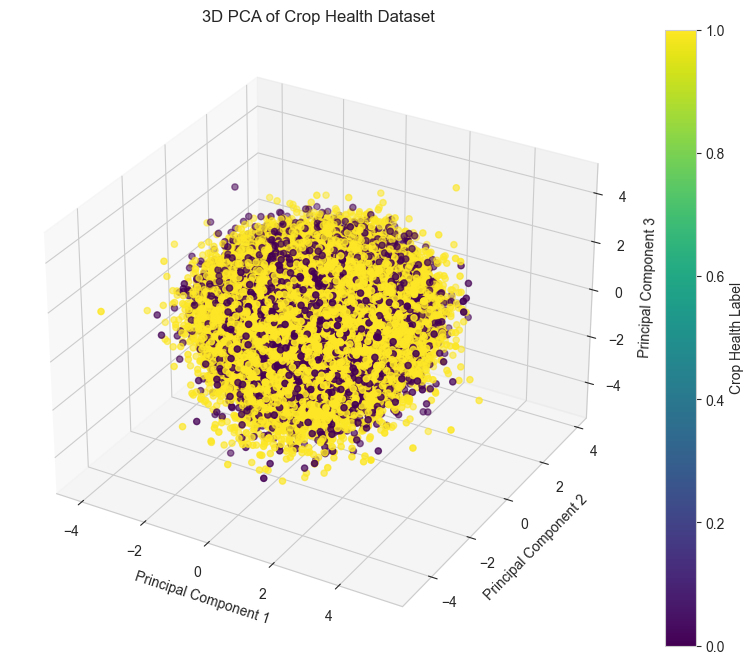

In [31]:
# PCA to visualize the data in 3D

# Standardize the features (if not already done)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_pca[:-1]])  # Exclude the target variable

# Apply PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_features)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Crop_Health_Label'] = df['Crop_Health_Label']

# Visualize in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['Crop_Health_Label'].astype('category').cat.codes, cmap='viridis')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of Crop Health Dataset')
plt.colorbar(scatter, label='Crop Health Label')
plt.show()

In [12]:
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each principal component: {explained_variance}')

Explained variance by each principal component: [0.03302101 0.03295121 0.03282268]


In [13]:
# pca with more components to see how much variance is explained by the first few components
pca = PCA(n_components=20)
pca_result = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each principal component: {explained_variance}')

Explained variance by each principal component: [0.03302101 0.03295121 0.03282268 0.03277959 0.03273901 0.03265709
 0.03258786 0.03255531 0.03254691 0.03248952 0.03247853 0.03238058
 0.03233763 0.03230835 0.03227382 0.03225973 0.03219509 0.03218827
 0.0321285  0.03210056]


### Diving into interesing boxplots

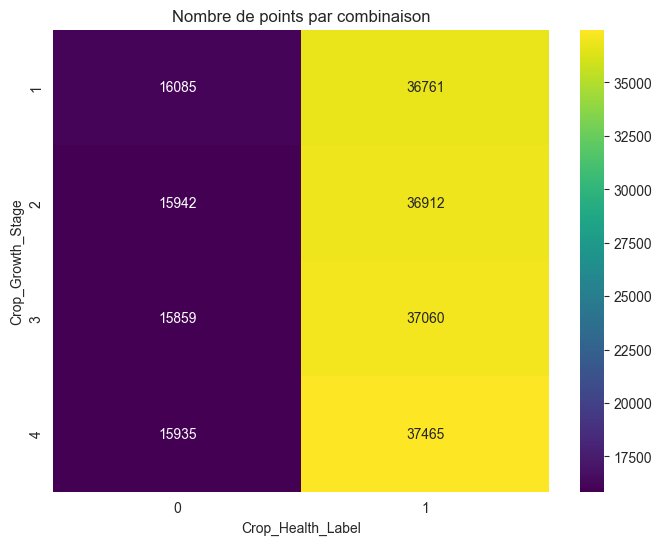

In [14]:
# Compter les occurrences
heatmap_data = df.groupby(["Crop_Growth_Stage", "Crop_Health_Label"]).size().unstack()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="viridis")

plt.title("Nombre de points par combinaison")
plt.xlabel("Crop_Health_Label")
plt.ylabel("Crop_Growth_Stage")

plt.show()

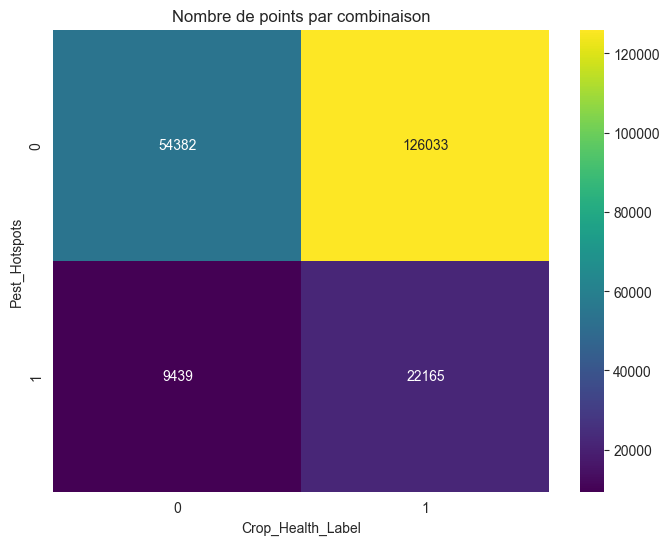

In [15]:
# plot crop health label and pest hotspots en comptant le nombre d'occurrences de chaque combinaison
heatmap_data = df.groupby(["Pest_Hotspots", "Crop_Health_Label"]).size().unstack()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="viridis")

plt.title("Nombre de points par combinaison")
plt.xlabel("Crop_Health_Label")
plt.ylabel("Pest_Hotspots")

plt.show()

### Checking the other variable of interest: expected yield (kg/ha)

In [ ]:
# Look at impact of variance of features on the target variable: Expected_Yield
df["Expected_Yield"].describe()

count    212019.000000
mean       3003.456310
std         797.669541
min        -468.653721
25%        2467.295493
50%        3003.479378
75%        3539.738947
max        6684.320978
Name: Expected_Yield, dtype: float64

In [19]:
# discretize expected yield into 3 categories: low, medium, high
df["Expected_Yield_Category"] = pd.qcut(df["Expected_Yield"], q=3, labels=["Low", "Medium", "High"])
df[["Expected_Yield", "Expected_Yield_Category"]].head()

,Expected_Yield,Expected_Yield_Category
0,2540.784327,Low
1,3227.617025,Medium
2,4609.938146,High
3,1409.716754,Low
4,3905.312588,High


C:\Users\jeanf\AppData\Local\Temp\ipykernel_38368\3891237188.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(["Expected_Yield_Category", "Crop_Health_Label"]).size().unstack()


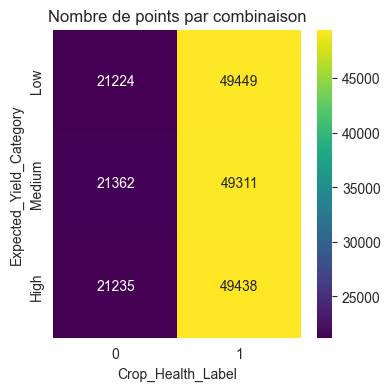

In [21]:
# Compter les occurrences
heatmap_data = df.groupby(["Expected_Yield_Category", "Crop_Health_Label"]).size().unstack()

# Plot
plt.figure(figsize=(4,4))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="viridis")

plt.title("Nombre de points par combinaison")
plt.xlabel("Crop_Health_Label")
plt.ylabel("Expected_Yield_Category")

plt.show()

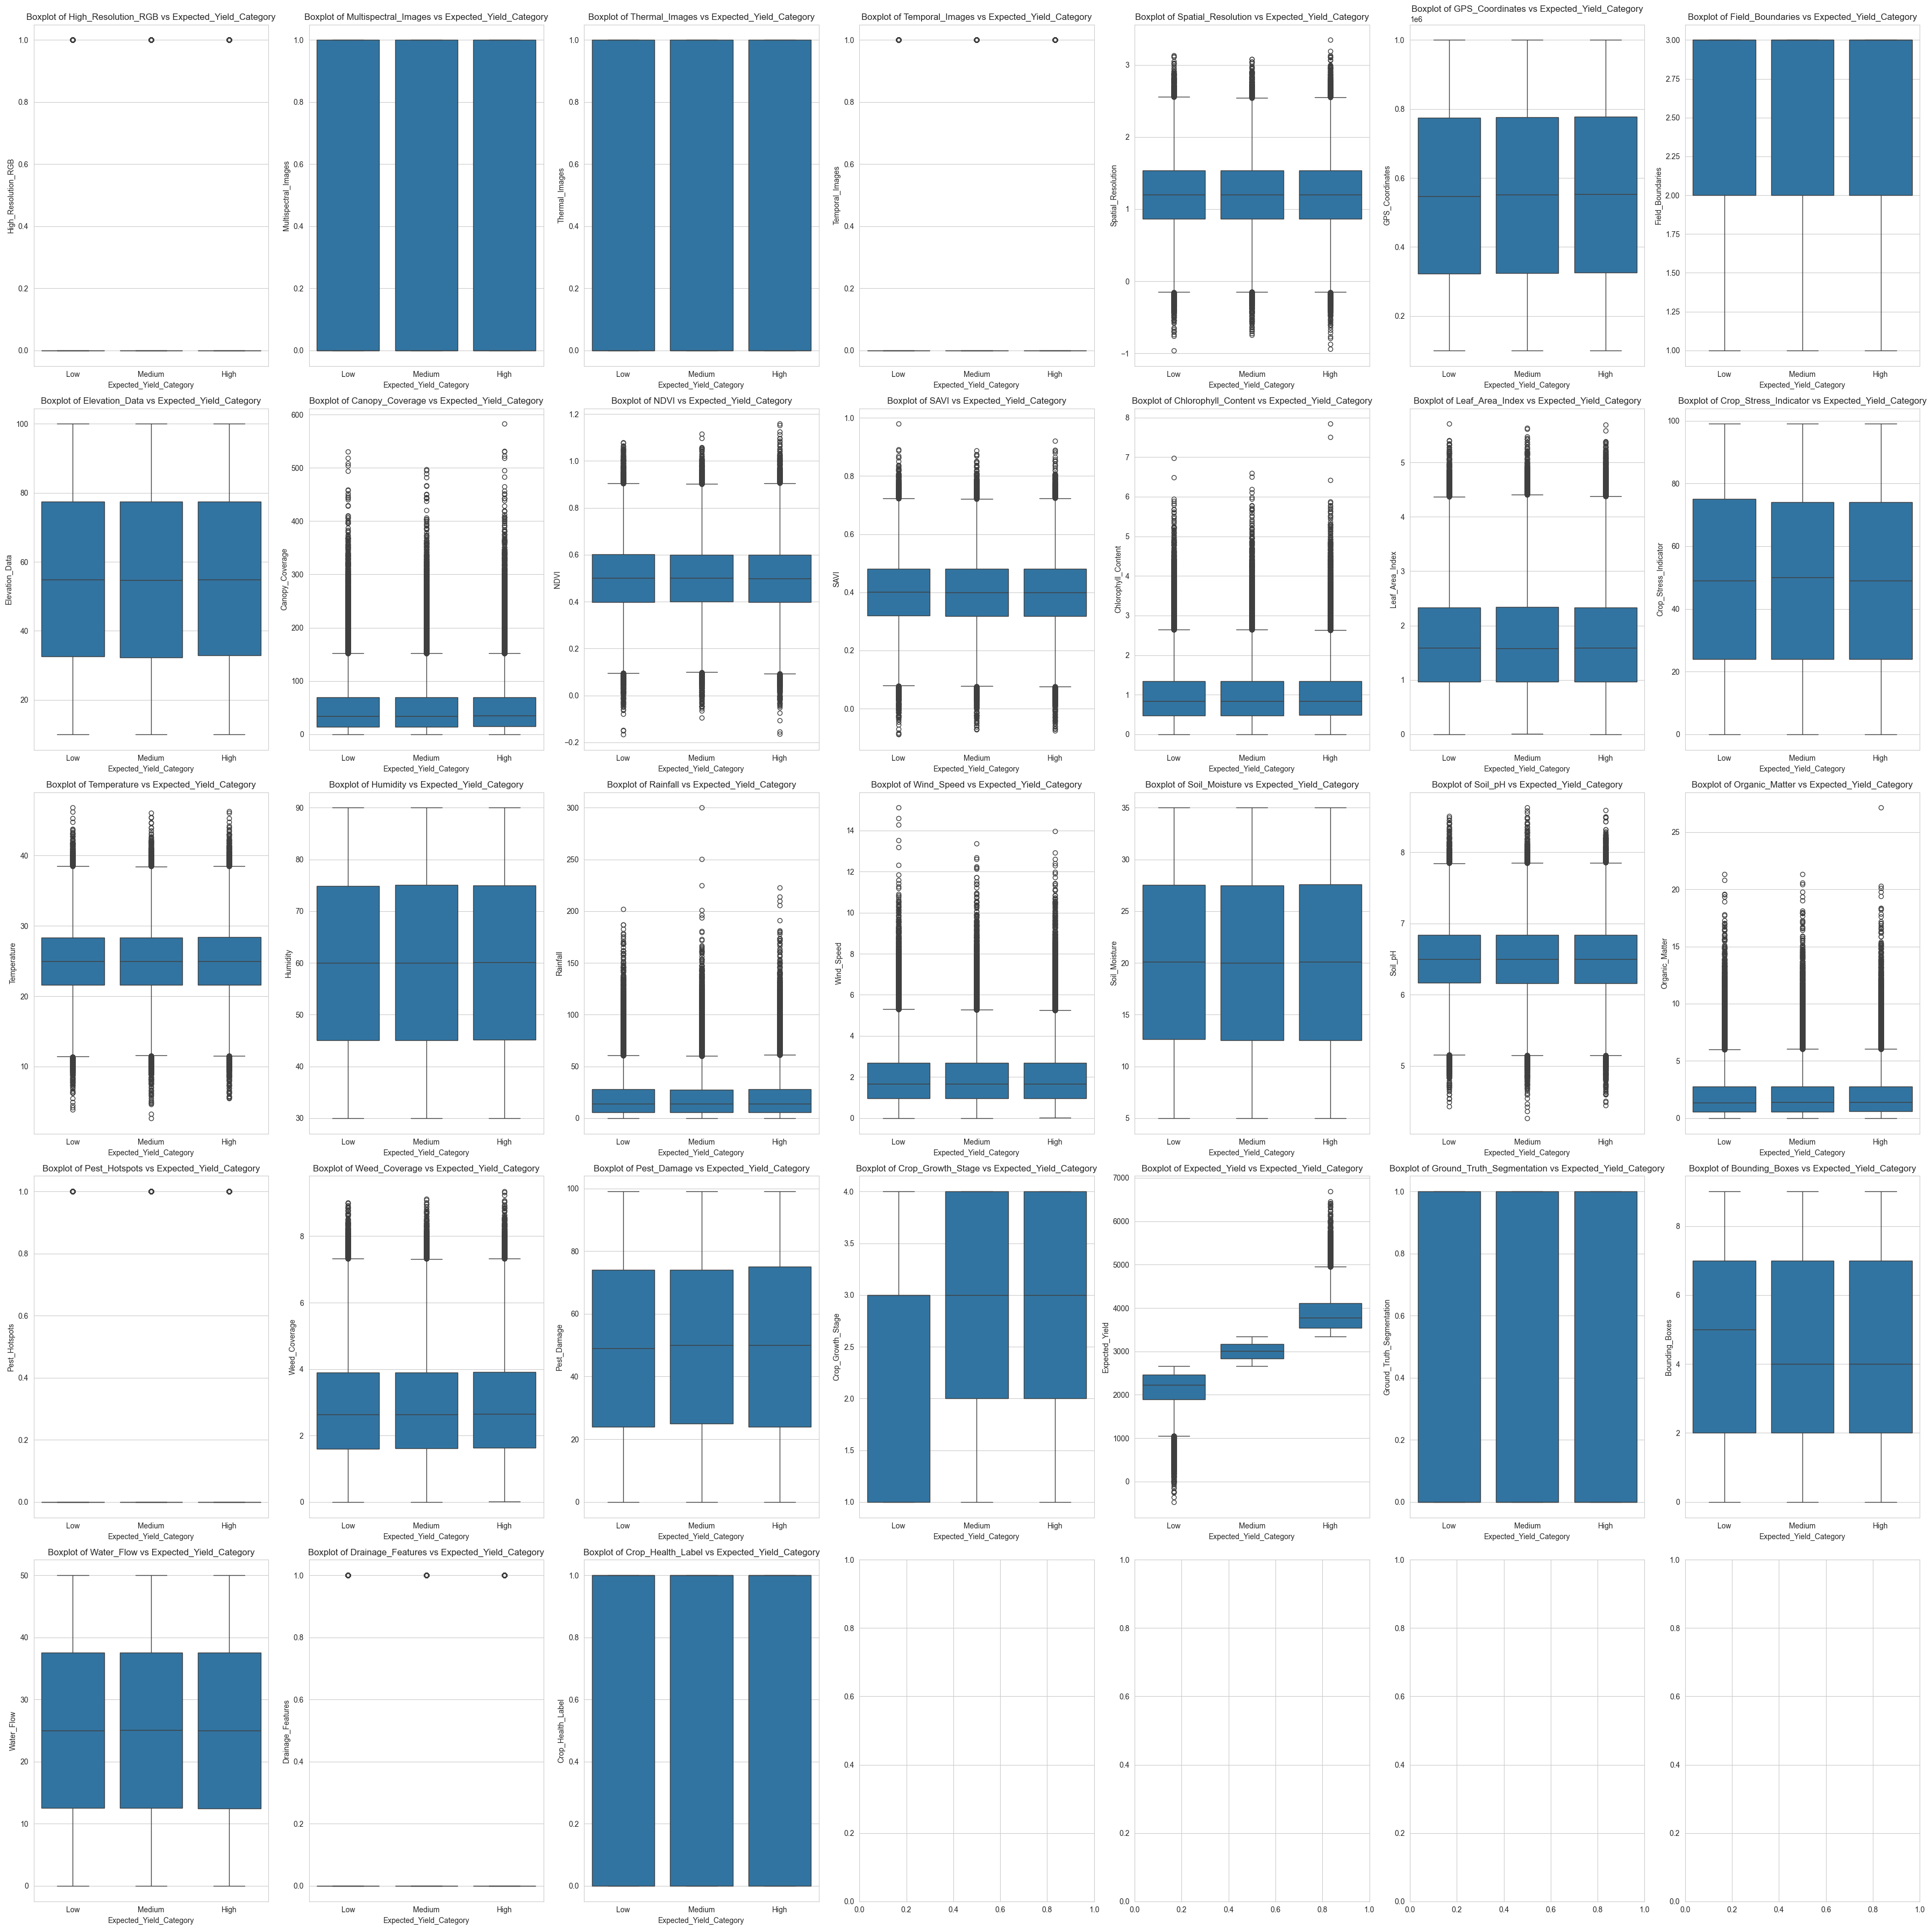

In [23]:
# Look at impact of variance of features on the target variable: Expected_Yield_Category
# We can use boxplots to visualize the relationship between each feature and the target variable
# Create a figure with subplots
fig, axes = plt.subplots(nrows=5, ncols=7, figsize=(36, 36))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
# Loop through each feature and create a boxplot
for i, feature in enumerate(features):
    sns.boxplot(x="Expected_Yield_Category", y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} vs Expected_Yield_Category')
    axes[i].set_xlabel('Expected_Yield_Category')
    axes[i].set_ylabel(feature)
# Adjust layout
plt.tight_layout()
plt.show()


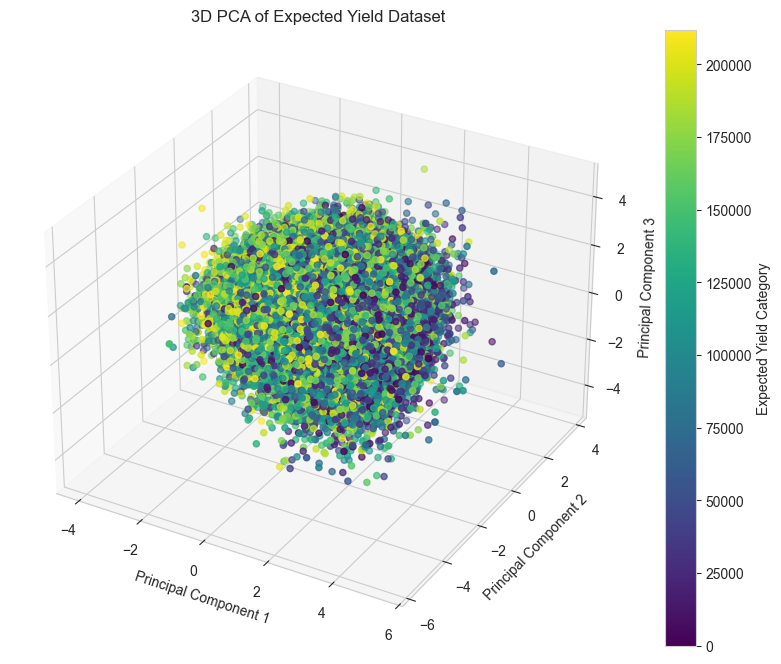

In [34]:
#pca
# PCA to visualize the data in 3D
# Standardize the features (if not already done)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_pca])
# Apply PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_features)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
pca_df['Expected_Yield'] = df['Expected_Yield']

# Visualize in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['Expected_Yield'].astype('category').cat.codes, cmap='viridis')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of Expected Yield Dataset')
plt.colorbar(scatter, label='Expected Yield Category')
plt.show()

In [35]:
# pca with more components to see how much variance is explained by the first few components
pca = PCA(n_components=20)
pca_result = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each principal component: {explained_variance}')

Explained variance by each principal component: [0.04849616 0.04834869 0.04823281 0.04814165 0.04805508 0.04791177
 0.04787405 0.04773791 0.04771619 0.04765393 0.04763013 0.04756109
 0.04752353 0.04741862 0.04733201 0.04728967 0.04718997 0.04710479
 0.04706495 0.04690598]
